In [ ]:
## REGRESSION

In [ ]:
# please uncomment this if running on Colab
!pip install tensorflow==1.14.0

In [ ]:
import random
#For reproducing the result 
from numpy.random import seed
seed(2)
from tensorflow import set_random_seed
set_random_seed(2)

import pandas as pd
import numpy as np
from sklearn import preprocessing
import math
import statistics

save_model = 'regression_deep_ensemble_model.h5'

## Import Data

In [ ]:
# Import Data
dataframe_training = pd.read_csv('train_FD004.txt', sep= " ", header=None)
dataframe_testing = pd.read_csv('test_FD004.txt', sep= " ", header=None)
dataframe_truth = pd.read_csv('RUL_FD004.txt', sep=" ", header=None)

#Removing empty columns 26 and 27 from the raw training data
dataframe_training = dataframe_training.drop(dataframe_training.columns[[26, 27]], axis=1)

#Removing empty columns 26 and 27 from the raw test data
dataframe_testing = dataframe_testing.drop(dataframe_testing.columns[[26, 27]], axis=1)

engine_unit_cycle = ['engine_unit', 'cycle_number']
operational_settings = ['1_Op_setting', '2_Op_setting', '3_Op_setting']
sensors = ['sensor-number_{}'.format(i) for i in range(1,22)] 
columns = engine_unit_cycle + operational_settings + sensors

# Naming the columns for training data
dataframe_training.columns = columns
dataframe_testing.columns = columns

#ground truth data
dataframe_truth = dataframe_truth.drop(dataframe_truth.columns[[1]], axis=1)

#dataframe_training.head()
#dataframe_testing.head()
#dataframe_truth.tail()


## Preprocessing

In [ ]:
# Creating labels for the training set
def create_RUL_label(dataframe):
  # Create label colunm i.e the Remaining Life 
  Remaining_Life = pd.DataFrame(dataframe.groupby('engine_unit')['cycle_number'].max()).reset_index()
  Remaining_Life.columns = ['engine_unit', 'last_cycle']
  dataframe = dataframe.merge(Remaining_Life, on=['engine_unit'], how='left')
  #dataframe = dataframe.merge(Remaining_Life, left_on=['engine_unit'], right_index=False)
  dataframe['Remaining_Life'] = dataframe['last_cycle'] - dataframe['cycle_number']
  dataframe.drop('last_cycle', axis=1, inplace=True)

  return (dataframe)


#Normalization
def normalise(dataframe):

  # Create a new column in the dataframe
  dataframe['cycle_norm'] = dataframe['cycle_number']

  # We wont normalise the index, cycle_number and the label
  normalised_columns = dataframe.columns.difference(['engine_unit','cycle_number','Remaining_Life'])

  normaliser = preprocessing.Normalizer()

  normalised_dataframe = pd.DataFrame(normaliser.fit_transform(dataframe[normalised_columns]), 
                             columns=normalised_columns, 
                             index=dataframe.index)

  Non_Normalised = dataframe[dataframe.columns.difference(normalised_columns)]

  join_df = Non_Normalised.join(normalised_dataframe)

  dataframe = join_df.reindex(columns = dataframe.columns)

  return dataframe

# Creating labels for the testset
def create_RUL_label_test (dataframe_testing, dataframe_truth):

  Remaining_Life = pd.DataFrame(dataframe_testing.groupby('engine_unit')['cycle_number'].max()).reset_index()
  Remaining_Life.columns = ['engine_unit', 'last_cycle']

  dataframe_truth.columns = ['remaining']
  dataframe_truth['engine_unit'] = dataframe_truth.index + 1
  
  dataframe_truth['last_cycle'] = Remaining_Life['last_cycle'] + dataframe_truth['remaining']
  dataframe_truth.drop('remaining', axis=1, inplace=True)

  # RUL for testing dataset
  dataframe_testing = dataframe_testing.merge(dataframe_truth, on=['engine_unit'], how='left')
  dataframe_testing['Remaining_Life'] = dataframe_testing['last_cycle'] - dataframe_testing['cycle_number']
  dataframe_testing.drop('last_cycle', axis=1, inplace=True)

  return dataframe_testing


""" Add label """
dataframe_training = create_RUL_label(dataframe_training)
#dataframe_training.head()

""" Normalise training set data """
dataframe_training = normalise(dataframe_training)
#dataframe_training.tail()

""" Normalise test set data """
dataframe_testing = normalise(dataframe_testing)
dataframe_testing.tail()

""" Add label """
dataframe_testing = create_RUL_label_test(dataframe_testing, dataframe_truth)
dataframe_testing.tail()

,engine_unit,cycle_number,1_Op_setting,2_Op_setting,3_Op_setting,sensor-number_1,sensor-number_2,sensor-number_3,sensor-number_4,sensor-number_5,sensor-number_6,sensor-number_7,sensor-number_8,sensor-number_9,sensor-number_10,sensor-number_11,sensor-number_12,sensor-number_13,sensor-number_14,sensor-number_15,sensor-number_16,sensor-number_17,sensor-number_18,sensor-number_19,sensor-number_20,sensor-number_21,cycle_norm,Remaining_Life
41209,248,277,0.003374,0.000067,0.008034,0.035750,0.044209,0.109612,0.090714,0.000314,0.000460,0.011114,0.177733,0.670952,0.000082,0.003398,0.010514,0.191885,0.651742,0.000759,0.000002,0.026592,0.177705,0.008034,0.000846,0.000503,0.022253,30
41210,248,278,0.001564,0.000055,0.007821,0.038414,0.047549,0.116899,0.098609,0.000731,0.001068,0.026180,0.181770,0.684985,0.000084,0.003483,0.024597,0.186783,0.632441,0.000726,0.000002,0.028624,0.181752,0.007821,0.001903,0.001146,0.021741,29
41211,248,279,0.002809,0.000068,0.008026,0.036073,0.044619,0.110010,0.090773,0.000440,0.000642,0.015645,0.178466,0.671825,0.000082,0.003397,0.014669,0.191715,0.650183,0.000754,0.000002,0.026968,0.178421,0.008026,0.001179,0.000709,0.022393,28
41212,248,280,0.001565,0.000055,0.007824,0.038432,0.047587,0.116512,0.098293,0.000732,0.001069,0.026067,0.181852,0.684864,0.000084,0.003504,0.024582,0.186873,0.632613,0.000726,0.000002,0.028637,0.181837,0.007824,0.001912,0.001149,0.021908,27
41213,248,281,0.002806,0.000067,0.008016,0.036029,0.044603,0.110512,0.091443,0.000439,0.000641,0.015573,0.178244,0.672812,0.000082,0.003373,0.014580,0.191479,0.649181,0.000753,0.000002,0.026855,0.178204,0.008016,0.001180,0.000709,0.022526,26


In [ ]:
def generating_sequence(unit_dataframe, seq_len, sequence_columns):
        
    # A single matrix contains all the rows of a single engine unit 
    matrix = unit_dataframe[sequence_columns].values 
    Number_of_rows = matrix.shape[0]
    #print('Number of rows in this particular engine unit', Number_of_rows)
    
    # Adjusted Python indexing
    for begin, end in zip(range(0, Number_of_rows - (seq_len)), range(seq_len, (Number_of_rows))):
        yield matrix[begin:end,  :]

# Sequence Length
seq_len = 30

# The generating_sequence() function creates the following sequences, here 30 is the sequence length.
# It takes as follows:
# row 0 to 30
# row 1 to 31
# row 2 to 32
# ... and so on

features = ['cycle_norm', '1_Op_setting', '2_Op_setting', '3_Op_setting']
features.extend(sensors)


new_list=list(generating_sequence(dataframe_training[dataframe_training['engine_unit']==1], seq_len, features))
print( 'Length after substracting the sequence length', len(new_list))


# converting each engine engine_unit to a sequence
# sequence_generator is a Generator object
sequence_generator = (list(generating_sequence(dataframe_training[dataframe_training['engine_unit']==engine_unit], seq_len, features)) for engine_unit in dataframe_training['engine_unit'].unique())

new_list = list(sequence_generator)

# function astype() is used to convert the generator object to an array of float type
seq_arr_list = np.concatenate(new_list).astype(np.float32)


# Generating labels
def generating_labels(unit_dataframe, length_of_sequence, label_value):
    matrix = unit_dataframe[label_value].values
    Number_of_rows = matrix.shape[0]
    #print ('matrix[length_of_sequence:Number_of_rows, :]', matrix[length_of_sequence:Number_of_rows, :])
    return matrix[length_of_sequence:Number_of_rows, :]


label_generator = [generating_labels(dataframe_training[dataframe_training['engine_unit']==engine_unit], seq_len, ['Remaining_Life']) for engine_unit in dataframe_training['engine_unit'].unique()]

# converting it to array of type float
labels = np.concatenate(label_generator).astype(np.float32)


Length after substracting the sequence length 291


### Deep Ensemble


In [ ]:
from tensorflow import keras 
import tensorflow.keras.backend as K
from tensorflow.python.keras.layers.core import Activation
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping

# Keras Callbacks
regulariser = EarlyStopping(monitor='val_loss', 
                            patience=20,  
                            mode='auto')

checkpoint_taken = ModelCheckpoint(save_model, 
                                   mode='auto', 
                                   monitor='val_loss',
                                   save_best_only=True) 
                            

In [ ]:
# RMSE
def root_mean_sq_error (y_true, y_prediction):
    return K.sqrt(K.mean(K.square(y_prediction - y_true), axis=-1))

# Coefficient of Determination (R2)
def r2(y_true, y_prediction):
    Sum_Sq_Residuals =  K.sum(K.square( y_true - y_prediction ))
    Sum_Sq_Total = K.sum(K.square( y_true - K.mean(y_true)))
    r2 =  1 - Sum_Sq_Residuals/(Sum_Sq_Total + K.epsilon())

    return r2

# Custom loss function
def regression_nll_loss(variance):

    def negative_log_likelihood(y_true, y_prediction):
        nll = 0.5 * K.mean((K.log(variance + 1e-6)) +(K.square(y_true - y_prediction) / (variance + 1e-6)))
        return nll

    return negative_log_likelihood

In [ ]:
class EnsembleModel():
    
    def __init__(self, nn_function=None, nn_number=None):
        
        # initialising
        self.nn_number = nn_number          
        self.train = [None] * nn_number 
        self.test = [None] * nn_number
            
        # loop through the number of times as provided by the user (i.e. number of neural network models for the ensemble) 
        for i in range(self.nn_number):
                                  
            # These are the two outputs returned by the neural_network() function
            train_model, pred_model = nn_function()                    
                                   
            # assign the output of the neural_networks() function to the local attributes
            self.train[i] = train_model
            self.test[i] = pred_model          
    

    def fit(self, X, y, epochs=10, batch_size=32, **kwargs):

        for i in range(self.nn_number):
            
            # Using Recursion
            self.train[i].fit(X, y, epochs=epochs, batch_size=batch_size, **kwargs)
           

    def predict(self, X, batch_size=32, num_ensembles = None):
              
        all_predictions = []
        variances = []
       
        if num_ensembles is None:
            estimators = self.test
        else:
            estimators = self.test[:num_ensembles]

        for element in estimators:
            # using resursion
            prediction, var = element.predict(X, batch_size=batch_size)

            all_predictions.append(prediction)
            variances.append(var)

        all_predictions = np.array(all_predictions)
        
        print('Size of all_predictions Array', all_predictions.shape)
                
        variances = np.array(variances)
        print('Size of Variances Array', variances.shape)
        
        mixture_mean = np.mean(all_predictions, axis=0)
        
        """ calculation of the mixture variance is based on the DeepEnsemble paper page 5 """
        mixture_var  = np.mean(variances + np.square(all_predictions), axis=0) - np.square(mixture_mean)
        
        # variance can not be less than zero, so for any spurious negative values, assign 0 to it.
        mixture_var[mixture_var < 0.0] = 0.0
                
        variance_aleatoric = np.mean(variances, axis=0)
        variance_epistemic = np.var(all_predictions, axis=0)
        
        mix_var = np.mean(mixture_var)
        
        #print('sqrt(variance_aleatoric)', np.sqrt(variance_aleatoric))
        #print('sqrt(variance_epistemic)', np.sqrt(variance_epistemic))
        #print('sqrt(mix_var)', np.sqrt(mix_var))

        return mixture_mean, np.sqrt(variance_aleatoric), np.sqrt(variance_epistemic),  np.sqrt(mix_var)

In [ ]:
num_of_features = seq_arr_list.shape[2]
print('num_of_features', num_of_features)
print('Sequence Length', seq_len)

def neural_networks():
    input_layer = Input((seq_len, num_of_features))
    
    """ Hidden Layer 1 with 100 neurons """
    lstm_1 = LSTM(100, activation='relu') (input_layer)

    """ Dropout applied to LSTM layer """
    dropout = Dropout(0.2)(lstm_1)

    """ Hidden Layer 2 with 30 neurons """
    dense = Dense(30, activation="relu")(dropout)

    dropout = Dropout(0.2)(dense)

    #""" Hidden Layer 3 with 30 neurons """
    #dense = Dense(30, activation="relu")(dropout)
    
    # outputs
    mean = Dense(1, activation="linear")(dense)
    standard_deviation = Dense(1, activation="softplus")(dense)

    train_model = Model(input_layer, mean)
    pred_model = Model(input_layer, [mean, standard_deviation])

    # Since the standard_deviation output of each members in the deep ensemble does not have direct supervision, 
    # unlike the mean (i.e the mean is supervised by the target y), therefore, the standard_deviation is indirectly
    # supervised by the loss function NLL, but without a target value. 
    # So passing the standard_deviation tensor to the loss is a workaround to a limitation in keras, in which case, the training model does not output
    # the standard_deviation directly, but the standard_deviation tensor is included in the loss function so it influences the loss correctly.

    optimizer = keras.optimizers.Adam(learning_rate=0.01)

    train_model.compile(loss=regression_nll_loss(standard_deviation), optimizer = optimizer, metrics=[root_mean_sq_error, r2])
    
    print(train_model.summary())

    return train_model, pred_model

num_of_features 25
Sequence Length 30


In [ ]:
""" 
The Class 'EnsembleModel' has been called passing in two arguments:
1st argument is the function used for creating the neural_networks.  
2nd argument is the number of Neural Network models the user want for the Ensemble. 
"""
model = EnsembleModel(neural_networks, 3)

Model: "model_30"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_16 (InputLayer)        [(None, 30, 25)]          0         
_________________________________________________________________
lstm_15 (LSTM)               (None, 100)               50400     
_________________________________________________________________
dropout_30 (Dropout)         (None, 100)               0         
_________________________________________________________________
dense_45 (Dense)             (None, 30)                3030      
_________________________________________________________________
dense_46 (Dense)             (None, 1)                 31        
Total params: 53,461
Trainable params: 53,461
Non-trainable params: 0
_________________________________________________________________
None
Model: "model_32"
_________________________________________________________________
Layer (type)                 Ou

### Training and Validation 

In [ ]:
# For experimentation purpose change epoch number

history = model.fit(seq_arr_list, labels, epochs= 10,  validation_split=0.10, verbose=2, batch_size=150,
          callbacks = [regulariser, checkpoint_taken])


Train on 48401 samples, validate on 5378 samples
Epoch 1/10
48401/48401 - 24s - loss: 131.1805 - root_mean_sq_error: 216.6490 - r2: -1.3547e+02 - val_loss: 4.8456 - val_root_mean_sq_error: 64.4874 - val_r2: -3.9855e-02
Epoch 2/10
48401/48401 - 20s - loss: 5.0180 - root_mean_sq_error: 70.5969 - r2: -1.1623e-01 - val_loss: 4.8290 - val_root_mean_sq_error: 62.1545 - val_r2: 0.0229
Epoch 3/10
48401/48401 - 20s - loss: 5.0030 - root_mean_sq_error: 72.7636 - r2: -2.7615e-01 - val_loss: 4.8739 - val_root_mean_sq_error: 62.1202 - val_r2: 0.0070
Epoch 4/10
48401/48401 - 20s - loss: 4.9529 - root_mean_sq_error: 68.0944 - r2: -2.9686e-02 - val_loss: 4.8422 - val_root_mean_sq_error: 61.3453 - val_r2: -3.2811e-02
Epoch 5/10
48401/48401 - 20s - loss: 4.9772 - root_mean_sq_error: 69.3370 - r2: -1.4338e-01 - val_loss: 4.8461 - val_root_mean_sq_error: 62.8669 - val_r2: -7.6405e-03
Epoch 6/10
48401/48401 - 20s - loss: 4.9589 - root_mean_sq_error: 68.8030 - r2: -4.6056e-02 - val_loss: 4.8374 - val_root_m

In [ ]:
y_prediction_mean, y_prediction_std_alea, y_prediction_std_epi, y_prediction_std_mix  = model.predict(seq_arr_list, batch_size=200)
y_true = labels

y_prediction_mean = y_prediction_mean.flatten()

print('Shape of y_prediction_mean', y_prediction_mean.shape)

print('y_prediction_mean', y_prediction_mean)
print('y_prediction_std_alea', np.mean(y_prediction_std_alea))
print('y_prediction_std_epi', np.mean(y_prediction_std_epi))
print('y_prediction_std_mix', np.mean(y_prediction_std_mix))

Size of all_predictions Array (3, 53779, 1)
Size of Variances Array (3, 53779, 1)
Shape of y_prediction_mean (53779,)
y_prediction_mean [140.06743 139.40776 138.69972 ...  71.05712  71.02922  71.06211]
y_prediction_std_alea 73.12215
y_prediction_std_epi 16.019024
y_prediction_std_mix 75.58407


### Model Evaluation on Test set

In [ ]:
# We want to take the final sequence for each engine_unit
test_sequence_array = [dataframe_testing[dataframe_testing['engine_unit']==engine_unit][features].values[-seq_len:] 
                       for engine_unit in dataframe_testing['engine_unit'].unique() if len(dataframe_testing[dataframe_testing['engine_unit']==engine_unit]) >= seq_len]

test_sequence_array = np.asarray(test_sequence_array).astype(np.float32)
print(test_sequence_array.shape)

# Labels for the test set
masking = [len(dataframe_testing[dataframe_testing['engine_unit']==engine_unit]) >= seq_len for engine_unit in dataframe_testing['engine_unit'].unique()]
labels_for_testing = dataframe_testing.groupby('engine_unit')['Remaining_Life'].nth(-1)[masking].values
labels_for_testing = labels_for_testing.reshape(labels_for_testing.shape[0],1).astype(np.float32)


(237, 30, 25)


In [ ]:
print ('test_sequence_array shape', test_sequence_array.shape)

y_prediction_mean_testset, y_prediction_std_test_alea, y_prediction_std_test_epi, y_prediction_std_test_mix = model.predict(test_sequence_array)

print("y pred mean shape: {}, y_prediction_std_test_epi shape: {}".format(y_prediction_mean_testset.shape, y_prediction_std_test_epi.shape))

y_truth_testset = labels_for_testing

# Reshape the outputs from the NN
y_prediction_mean_testset = y_prediction_mean_testset.reshape((-1,))
y_prediction_std_test_alea = y_prediction_std_test_alea.reshape((-1,))
y_prediction_std_test_epi = y_prediction_std_test_epi.reshape((-1,))
y_prediction_std_test_mix = y_prediction_std_test_mix.reshape((-1,))


print ('y_prediction_std_test_alea', np.mean(y_prediction_std_test_alea))
print ('y_prediction_std_test_epi', np.mean(y_prediction_std_test_epi))
print ('y_prediction_std_test_mix', np.mean(y_prediction_std_test_mix))

print("y pred mean shape: {}, y_prediction_std_test_epi shape: {}, y_prediction_std_test_alea shape:{}, y_prediction_std_test_mix shape: {}  after reshape".format(y_prediction_mean_testset.shape, y_prediction_std_test_epi.shape, y_prediction_std_test_alea.shape, y_prediction_std_test_mix.shape))


test_sequence_array shape (237, 30, 25)
Size of all_predictions Array (3, 237, 1)
Size of Variances Array (3, 237, 1)
y pred mean shape: (237, 1), y_prediction_std_test_epi shape: (237, 1)
y_prediction_std_test_alea 71.0959
y_prediction_std_test_epi 16.873
y_prediction_std_test_mix 73.82301
y pred mean shape: (237,), y_prediction_std_test_epi shape: (237,), y_prediction_std_test_alea shape:(237,), y_prediction_std_test_mix shape: (1,)  after reshape


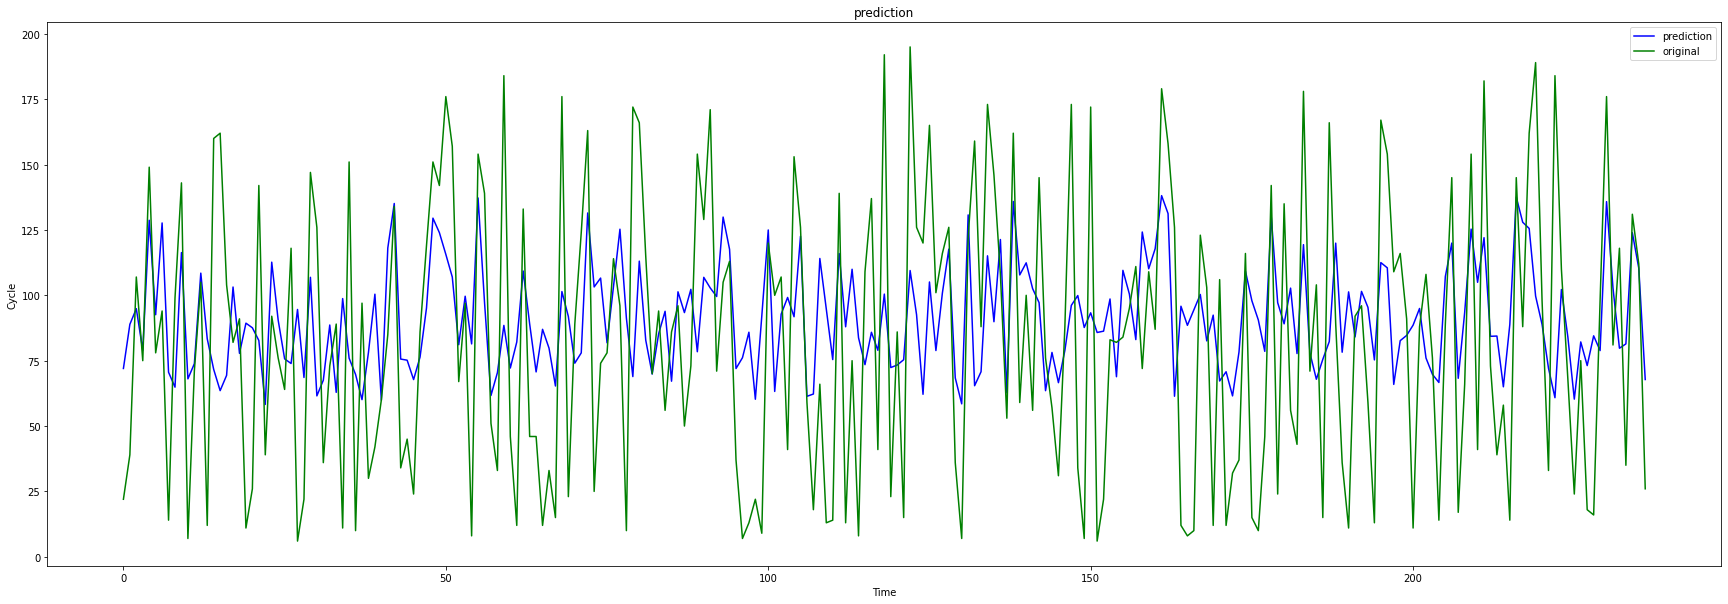

In [ ]:
import matplotlib
graph1 = matplotlib.pyplot.figure(figsize=(30, 10))
matplotlib.pyplot.plot(y_prediction_mean_testset, color="blue")

matplotlib.pyplot.plot(y_truth_testset, color="green")
matplotlib.pyplot.legend(['prediction', 'original', 'confidence_interval_upper', 'confidence_interval_lower'], loc='upper right')
matplotlib.pyplot.title('prediction')

matplotlib.pyplot.xlabel('Time')
matplotlib.pyplot.ylabel('Cycle')

matplotlib.pyplot.show()
graph1.savefig("prediction_regression.png")

#### Uncertainty (Mixture std)

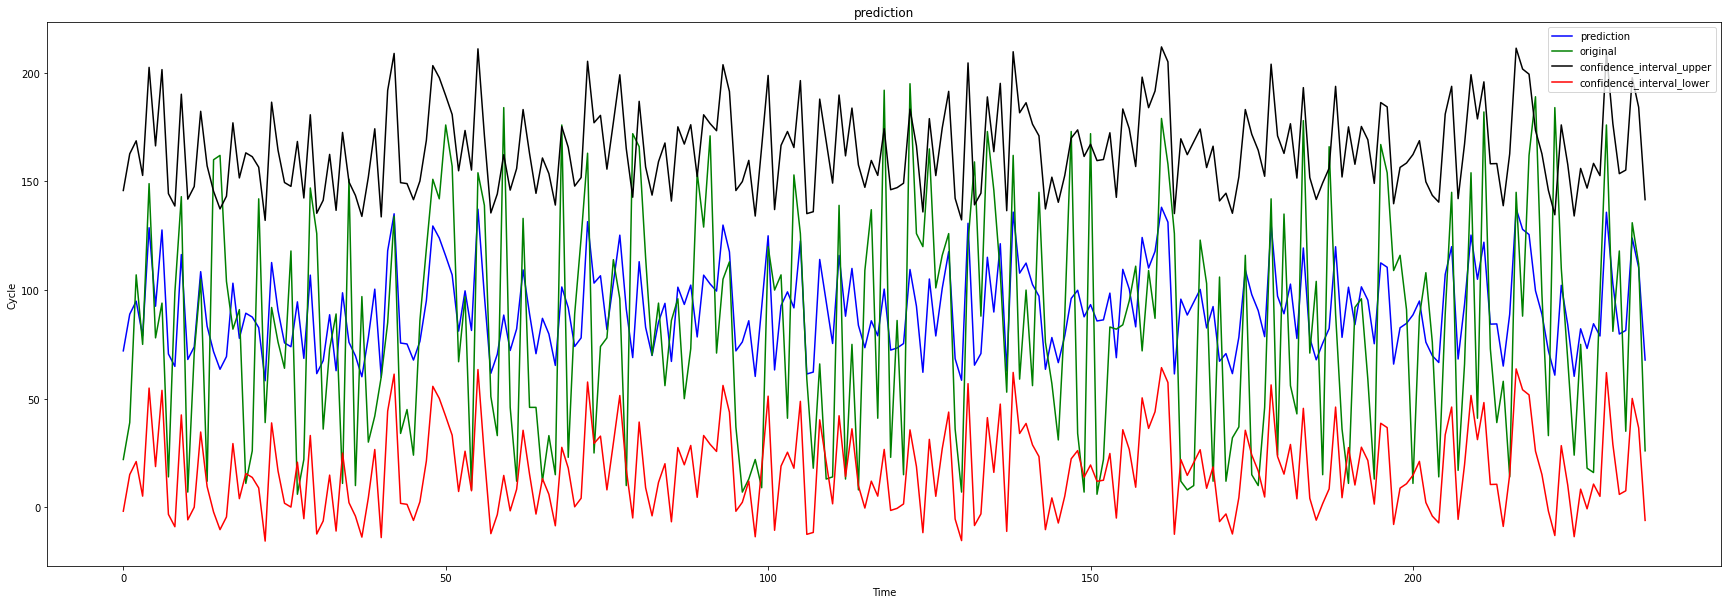

In [ ]:
y_prediction_up_mix = y_prediction_mean_testset + y_prediction_std_test_mix
y_prediction_down_mix = y_prediction_mean_testset - y_prediction_std_test_mix

y_prediction_up_2 = y_prediction_mean_testset + 2.0 * y_prediction_std_test_mix
y_prediction_down_2 = y_prediction_mean_testset - 2.0 * y_prediction_std_test_mix

y_prediction_up_3 = y_prediction_mean_testset + 3.0 * y_prediction_std_test_mix
y_prediction_down_3 = y_prediction_mean_testset - 3.0 * y_prediction_std_test_mix


graph2 = matplotlib.pyplot.figure(figsize=(30, 10))
matplotlib.pyplot.plot(y_prediction_mean_testset, color="blue")
matplotlib.pyplot.plot(y_truth_testset, color="green")

matplotlib.pyplot.plot(y_prediction_up_mix, color="black")
matplotlib.pyplot.plot(y_prediction_down_mix, color="red")
#matplotlib.pyplot.fill_between(y_prediction_mean_testset, y_prediction_up_1, y_prediction_down_1, alpha=0.30)

matplotlib.pyplot.title('prediction')

matplotlib.pyplot.xlabel('Time')
matplotlib.pyplot.ylabel('Cycle')
matplotlib.pyplot.legend(['prediction', 'original', 'confidence_interval_upper', 'confidence_interval_lower'], loc='upper right')
matplotlib.pyplot.show()
graph2.savefig("uncertainty_regression.png")

In [ ]:
y_truth_testset = y_truth_testset.flatten()


In [ ]:
def rms(y_truth_testset, y_prediction_mean_testset):
    arr = (y_truth_testset - y_prediction_mean_testset)** 2
    mean = statistics.mean(arr)
    to_return = math.sqrt(mean)
    return to_return

print('Root Mean Square Error on the Test set is:', rms(y_truth_testset, y_prediction_mean_testset))

Root Mean Square Error on the Test set is: 48.26000999226093


In [ ]:
def r2(y_true, y_prediction):
    SS_res =  np.sum(np.square( y_true - y_prediction ))
    SS_tot = np.sum(np.square( y_true - np.mean(y_true) ))
    return ( 1 - (SS_res/SS_tot))

print('R2 value is: ', r2(y_truth_testset, y_prediction_mean_testset))

R2 value is:  0.17828595638275146


In [ ]:
def neg_log_likelihood(y_true, y_prediction, std):
    term1 = np.log(y_prediction_std_test_alea**2 + 1e-6)
    
    term2 = ((y_true - y_prediction)**2) / (std**2 + 1e-6)
    
    nll = 0.5 * statistics.mean(term1 + term2)
    return nll

print('NLL value is: ', neg_log_likelihood(y_truth_testset, y_prediction_mean_testset, y_prediction_std_test_alea))

NLL value is:  4.50096321105957


In [ ]:
print('Mixture Uncertainty is: ', y_prediction_std_test_mix)

Mixture Uncertainty is:  [73.82301]


In [ ]:
print('Epistemic Uncertainty is: ', np.mean(y_prediction_std_test_epi))

Epistemic Uncertainty is:  16.873


In [ ]:
print('Aleatoric Uncertainty is: ', np.mean(y_prediction_std_test_alea))

Aleatoric Uncertainty is:  71.0959


### Reference

1. M.Valdenegro, Keras Uuncertainty, 2021.[Online].Available:
https://github.com/mvaldenegro/keras-uncertainty

2. Keras Metrics, Documentation - https://keras.io/api/metrics/regression_metrics/

3. Microsoft-Azure,“Deep learning for predictive maintenance,” 2017.[Online].Available:https://github.com/Azure/lstmsforpredictivemaintenance/

4. Mathworks - https://kr.mathworks.com/help/predmaint/ug/similarity-based-remaining-useful-life-estimation.html